# ConInstruct Hidden-State Projection Analysis

This notebook compares three prompt states for each ConInstruct single-conflict sample:

- `org`: the original expanded instruction
- `new`: the rewritten instruction containing only the new constraint side
- `conflict`: the original instruction plus the conflicting new constraint

It computes cosine and projection scores to estimate whether `h_conflict` is closer to `h_org` or `h_new`, then compares those scores with `conflict_resolution` and `conflict_resolution_behavior` evaluation outputs.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('.').resolve()

# Change this to analyze another downloaded model, e.g. 'Qwen/Qwen3.5-4B'.
MODEL_ID = 'Qwen/Qwen3.5-4B'
MODEL_SAFE = MODEL_ID.replace('/', '__')

HIDDEN_ROOT = ROOT / 'outputs' / 'coninstruct_hidden_states' / MODEL_SAFE
CONFLICT_HIDDEN_ROOT = HIDDEN_ROOT / 'conflict_resolution'
ORG_NEW_HIDDEN_ROOT = HIDDEN_ROOT / 'conflict_resolution_org_new'

PAIR_EVAL_ROOT = ROOT / 'evaluation_outputs' / 'conflict_resolution' / MODEL_ID
BEHAVIOR_EVAL_ROOT = ROOT / 'evaluation_outputs' / 'conflict_resolution' / 'behavior' / MODEL_ID

OUT_DIR = ROOT / 'analysis' / 'coninstruct_projection' / MODEL_SAFE
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('MODEL:', MODEL_ID)
print('Conflict hidden:', CONFLICT_HIDDEN_ROOT.exists(), CONFLICT_HIDDEN_ROOT)
print('Org/new hidden:', ORG_NEW_HIDDEN_ROOT.exists(), ORG_NEW_HIDDEN_ROOT)
print('Pair eval:', PAIR_EVAL_ROOT.exists(), PAIR_EVAL_ROOT)
print('Behavior eval:', BEHAVIOR_EVAL_ROOT.exists(), BEHAVIOR_EVAL_ROOT)

ROOT: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master
MODEL: Qwen/Qwen3.5-4B
Conflict hidden: True /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/outputs/coninstruct_hidden_states/Qwen__Qwen3.5-4B/conflict_resolution
Org/new hidden: True /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/outputs/coninstruct_hidden_states/Qwen__Qwen3.5-4B/conflict_resolution_org_new
Pair eval: True /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/evaluation_outputs/conflict_resolution/Qwen/Qwen3.5-4B
Behavior eval: True /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/evaluation_outputs/conflict_resolution/behavior/Qwen/Qwen3.5-4B


In [2]:
def load_json(path):
    with open(path, encoding='utf-8') as f:
        return json.load(f)


def load_metadata_examples(metadata_path):
    metadata = load_json(metadata_path)
    examples = pd.DataFrame(metadata['examples'])
    examples['key'] = list(zip(examples['conflict_type_idx'], examples['sample_id']))
    return metadata, examples


def available_layers(conflict_type_idx):
    paths = sorted((CONFLICT_HIDDEN_ROOT / f'conflict_type_{conflict_type_idx}').glob('layer_*.npy'))
    layers = []
    for path in paths:
        m = re.match(r'layer_(\d+)\.npy$', path.name)
        if m:
            layers.append(int(m.group(1)))
    return sorted(layers)


def normalize_rows(x, eps=1e-12):
    return x / np.maximum(np.linalg.norm(x, axis=1, keepdims=True), eps)


def parse_last_label(text, allowed=(1, 2, -1)):
    if not isinstance(text, str) or not text.strip():
        return -1
    lines = [line.strip() for line in text.strip().splitlines() if line.strip()]
    # Prefer the last nonempty line, matching the original evaluation.py behavior,
    # but tolerate punctuation or labels such as '**Step 3**: 1.'.
    search_space = lines[-3:][::-1]
    pattern = r'(?<!\d)-1(?!\d)|(?<!\d)[12](?!\d)'
    for line in search_space:
        matches = re.findall(pattern, line)
        if matches:
            value = int(matches[-1])
            if value in allowed:
                return value
    return -1


def map_pair_label(raw_label, instruction_order):
    # Return labels in the same semantics as evaluation.py after order correction:
    # 1 means new_constraint, 2 means org_constraint, -1 means neither/unknown.
    if instruction_order == 'org_new':
        if raw_label == 1:
            return 2
        if raw_label == 2:
            return 1
    return raw_label


PAIR_LABEL_NAMES = {1: 'new', 2: 'org', -1: 'neither'}
BEHAVIOR_LABEL_NAMES = {
    1: 'direct_answer_no_conflict_ack',
    2: 'asks_user_to_clarify',
    3: 'self_resolves_then_answers',
    4: 'other',
    -1: 'parse_failed',
}


def load_pair_eval_labels():
    rows = []
    for type_dir in sorted(PAIR_EVAL_ROOT.glob('*'), key=lambda p: int(p.name) if p.name.isdigit() else 999):
        if not type_dir.is_dir() or not type_dir.name.isdigit():
            continue
        conflict_type_idx = int(type_dir.name)
        for path in sorted(type_dir.glob('*.json'), key=lambda p: int(p.stem) if p.stem.isdigit() else 999):
            if path.name == 'results.json' or not path.stem.isdigit():
                continue
            sample_id = int(path.stem)
            data = load_json(path)
            conflict_keys = [k for k in data.keys() if k != 'llm_response']
            if not conflict_keys:
                continue
            conflict_key = conflict_keys[0]
            item = data[conflict_key]
            raw = parse_last_label(item.get('evaluation_result', ''), allowed=(1, 2, -1))
            mapped = map_pair_label(raw, item.get('instruction_order'))
            rows.append({
                'conflict_type_idx': conflict_type_idx,
                'sample_id': sample_id,
                'pair_raw_label': raw,
                'pair_label': mapped,
                'pair_label_name': PAIR_LABEL_NAMES.get(mapped, 'unknown'),
                'instruction_order': item.get('instruction_order'),
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df['key'] = list(zip(df['conflict_type_idx'], df['sample_id']))
    return df


def load_behavior_eval_labels():
    rows = []
    for type_dir in sorted(BEHAVIOR_EVAL_ROOT.glob('*'), key=lambda p: int(p.name) if p.name.isdigit() else 999):
        if not type_dir.is_dir() or not type_dir.name.isdigit():
            continue
        conflict_type_idx = int(type_dir.name)
        for path in sorted(type_dir.glob('*.json'), key=lambda p: int(p.stem) if p.stem.isdigit() else 999):
            if path.name == 'results.json' or not path.stem.isdigit():
                continue
            sample_id = int(path.stem)
            data = load_json(path)
            label = parse_last_label(data.get('evaluation_result', ''), allowed=(1, 2, 3, 4, -1))
            rows.append({
                'conflict_type_idx': conflict_type_idx,
                'sample_id': sample_id,
                'behavior_label': label,
                'behavior_label_name': BEHAVIOR_LABEL_NAMES.get(label, 'unknown'),
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df['key'] = list(zip(df['conflict_type_idx'], df['sample_id']))
    return df

In [3]:
conflict_meta, conflict_examples = load_metadata_examples(CONFLICT_HIDDEN_ROOT / 'metadata.json')
org_new_meta, org_new_examples = load_metadata_examples(ORG_NEW_HIDDEN_ROOT / 'metadata.json')

pair_labels = load_pair_eval_labels()
behavior_labels = load_behavior_eval_labels()

print('conflict examples:', len(conflict_examples))
print('org/new examples:', len(org_new_examples))
print('pair labels:', len(pair_labels))
print('behavior labels:', len(behavior_labels))

display(conflict_examples.groupby('conflict_type_idx').size().rename('conflict_hidden_count').to_frame().T)
display(org_new_examples.groupby(['conflict_type_idx', 'variant']).size().unstack(fill_value=0))
display(pair_labels['pair_label_name'].value_counts(dropna=False).rename('pair_label_count').to_frame())
display(behavior_labels['behavior_label_name'].value_counts(dropna=False).rename('behavior_label_count').to_frame())

conflict examples: 864
org/new examples: 1728
pair labels: 864
behavior labels: 864


conflict_type_idx,1,2,3,4,5,6,7,8,9
conflict_hidden_count,100,100,100,100,100,100,100,94,70


variant,new,org
conflict_type_idx,,
1,100,100
2,100,100
3,100,100
4,100,100
5,100,100
6,100,100
7,100,100
8,94,94
9,70,70


,pair_label_count
pair_label_name,
org,404
new,365
neither,95


,behavior_label_count
behavior_label_name,
direct_answer_no_conflict_ack,733
parse_failed,121
asks_user_to_clarify,10


In [4]:
def rows_for_variant(examples, conflict_type_idx, variant=None):
    subset = examples[examples['conflict_type_idx'] == conflict_type_idx].copy()
    if variant is not None:
        subset = subset[subset['variant'] == variant].copy()
    subset = subset.reset_index(drop=True)
    return subset


_LAYER_GLOBAL_MEAN_CACHE = {}


def layer_global_mean(layer):
    """Mean hidden state for one layer across conflict/org/new variants and all conflict types."""
    if layer in _LAYER_GLOBAL_MEAN_CACHE:
        return _LAYER_GLOBAL_MEAN_CACHE[layer]

    total = None
    count = 0
    for conflict_type_idx in sorted(conflict_examples['conflict_type_idx'].unique()):
        ctype = f'conflict_type_{int(conflict_type_idx)}'
        paths = [
            CONFLICT_HIDDEN_ROOT / ctype / f'layer_{layer}.npy',
            ORG_NEW_HIDDEN_ROOT / ctype / 'org' / f'layer_{layer}.npy',
            ORG_NEW_HIDDEN_ROOT / ctype / 'new' / f'layer_{layer}.npy',
        ]
        for path in paths:
            arr = np.load(path).astype(np.float64)
            arr_sum = arr.sum(axis=0)
            total = arr_sum if total is None else total + arr_sum
            count += arr.shape[0]

    mean = total / count
    _LAYER_GLOBAL_MEAN_CACHE[layer] = mean
    return mean


def compute_scores_for_type_layer(conflict_type_idx, layer):
    ctype = f'conflict_type_{conflict_type_idx}'
    h_conflict = np.load(CONFLICT_HIDDEN_ROOT / ctype / f'layer_{layer}.npy')
    h_org = np.load(ORG_NEW_HIDDEN_ROOT / ctype / 'org' / f'layer_{layer}.npy')
    h_new = np.load(ORG_NEW_HIDDEN_ROOT / ctype / 'new' / f'layer_{layer}.npy')

    conflict_rows = rows_for_variant(conflict_examples, conflict_type_idx)
    org_rows = rows_for_variant(org_new_examples, conflict_type_idx, 'org')
    new_rows = rows_for_variant(org_new_examples, conflict_type_idx, 'new')

    conflict_index = {key: i for i, key in enumerate(conflict_rows['key'])}
    org_index = {key: i for i, key in enumerate(org_rows['key'])}
    new_index = {key: i for i, key in enumerate(new_rows['key'])}
    keys = sorted(set(conflict_index) & set(org_index) & set(new_index))

    ci = np.array([conflict_index[k] for k in keys])
    oi = np.array([org_index[k] for k in keys])
    ni = np.array([new_index[k] for k in keys])

    hc = h_conflict[ci].astype(np.float64)
    ho = h_org[oi].astype(np.float64)
    hn = h_new[ni].astype(np.float64)

    # Raw cosine. This is often dominated by a large common hidden-state component.
    nc = normalize_rows(hc)
    no = normalize_rows(ho)
    nn = normalize_rows(hn)
    cos_org = np.sum(nc * no, axis=1)
    cos_new = np.sum(nc * nn, axis=1)
    cosine_delta = cos_new - cos_org

    # Centered cosine: remove one layer-level global mean before measuring angles.
    # The mean is computed across all conflict types and all three variants: conflict/org/new.
    mean = layer_global_mean(layer)
    hcc = hc - mean
    hoc = ho - mean
    hnc = hn - mean
    ncc = normalize_rows(hcc)
    noc = normalize_rows(hoc)
    nnc = normalize_rows(hnc)
    centered_cos_org = np.sum(ncc * noc, axis=1)
    centered_cos_new = np.sum(ncc * nnc, axis=1)
    centered_cosine_delta = centered_cos_new - centered_cos_org

    direction = hn - ho
    unit_direction = normalize_rows(direction)
    midpoint = (ho + hn) / 2.0
    projection = np.sum((hc - midpoint) * unit_direction, axis=1)
    endpoint_distance = np.linalg.norm(direction, axis=1)
    normalized_projection = projection / np.maximum(endpoint_distance / 2.0, 1e-12)

    rows = []
    for idx, key in enumerate(keys):
        rows.append({
            'model_id': MODEL_ID,
            'conflict_type_idx': key[0],
            'sample_id': key[1],
            'layer': layer,
            'cos_org': cos_org[idx],
            'cos_new': cos_new[idx],
            'cosine_delta': cosine_delta[idx],
            'centered_cos_org': centered_cos_org[idx],
            'centered_cos_new': centered_cos_new[idx],
            'centered_cosine_delta': centered_cosine_delta[idx],
            'projection': projection[idx],
            'normalized_projection': normalized_projection[idx],
            'predicted_side_cosine': 'new' if cosine_delta[idx] > 0 else 'org',
            'predicted_side_centered_cosine': 'new' if centered_cosine_delta[idx] > 0 else 'org',
            'predicted_side_projection': 'new' if projection[idx] > 0 else 'org',
        })
    return pd.DataFrame(rows)


all_score_frames = []
for conflict_type_idx in sorted(conflict_examples['conflict_type_idx'].unique()):
    layers = available_layers(conflict_type_idx)
    for layer in layers:
        all_score_frames.append(compute_scores_for_type_layer(conflict_type_idx, layer))

scores = pd.concat(all_score_frames, ignore_index=True)
if not pair_labels.empty:
    scores = scores.merge(pair_labels.drop(columns=['key']), on=['conflict_type_idx', 'sample_id'], how='left')
if not behavior_labels.empty:
    scores = scores.merge(behavior_labels.drop(columns=['key']), on=['conflict_type_idx', 'sample_id'], how='left')

scores.to_csv(OUT_DIR / 'sample_layer_scores.csv', index=False)
scores.head()


,model_id,conflict_type_idx,sample_id,layer,cos_org,cos_new,cosine_delta,centered_cos_org,centered_cos_new,centered_cosine_delta,...,normalized_projection,predicted_side_cosine,predicted_side_centered_cosine,predicted_side_projection,pair_raw_label,pair_label,pair_label_name,instruction_order,behavior_label,behavior_label_name
0,Qwen/Qwen3.5-4B,1,1,0,0.999958,0.999940,-0.000018,0.938954,0.914609,-0.024346,...,-0.802982,org,org,org,1,2,org,org_new,1,direct_answer_no_conflict_ack
1,Qwen/Qwen3.5-4B,1,2,0,0.999941,0.999862,-0.000079,0.970415,0.937585,-0.032830,...,-1.084344,org,org,org,2,2,org,new_org,1,direct_answer_no_conflict_ack
2,Qwen/Qwen3.5-4B,1,3,0,0.999938,0.999795,-0.000143,0.953911,0.814239,-0.139672,...,-1.006164,org,org,org,1,1,new,new_org,1,direct_answer_no_conflict_ack
3,Qwen/Qwen3.5-4B,1,4,0,0.999872,0.999787,-0.000085,0.833288,0.710808,-0.122480,...,-1.330011,org,org,org,1,1,new,new_org,1,direct_answer_no_conflict_ack
4,Qwen/Qwen3.5-4B,1,5,0,0.999954,0.999973,0.000019,0.973244,0.981604,0.008360,...,0.192384,new,new,new,1,2,org,org_new,1,direct_answer_no_conflict_ack


In [5]:
layer_summary = (
    scores.groupby('layer')
    .agg(
        n=('sample_id', 'count'),
        mean_cosine_delta=('cosine_delta', 'mean'),
        median_cosine_delta=('cosine_delta', 'median'),
        frac_cosine_new=('cosine_delta', lambda s: (s > 0).mean()),
        mean_centered_cosine_delta=('centered_cosine_delta', 'mean'),
        median_centered_cosine_delta=('centered_cosine_delta', 'median'),
        frac_centered_cosine_new=('centered_cosine_delta', lambda s: (s > 0).mean()),
        mean_projection=('projection', 'mean'),
        median_projection=('projection', 'median'),
        frac_projection_new=('projection', lambda s: (s > 0).mean()),
        mean_normalized_projection=('normalized_projection', 'mean'),
    )
    .reset_index()
)

labelled = scores[scores['pair_label_name'].isin(['new', 'org'])].copy()
agreement_by_layer = (
    labelled.groupby('layer')
    .apply(lambda g: pd.Series({
        'n_labelled': len(g),
        'cosine_agreement': (g['predicted_side_cosine'] == g['pair_label_name']).mean(),
        'centered_cosine_agreement': (g['predicted_side_centered_cosine'] == g['pair_label_name']).mean(),
        'projection_agreement': (g['predicted_side_projection'] == g['pair_label_name']).mean(),
        'pair_new_rate': (g['pair_label_name'] == 'new').mean(),
    }))
    .reset_index()
)

type_summary = (
    scores.groupby(['conflict_type_idx', 'layer'])
    .agg(
        n=('sample_id', 'count'),
        mean_cosine_delta=('cosine_delta', 'mean'),
        frac_cosine_new=('cosine_delta', lambda s: (s > 0).mean()),
        mean_centered_cosine_delta=('centered_cosine_delta', 'mean'),
        frac_centered_cosine_new=('centered_cosine_delta', lambda s: (s > 0).mean()),
        mean_projection=('projection', 'mean'),
        frac_projection_new=('projection', lambda s: (s > 0).mean()),
    )
    .reset_index()
)

layer_summary.to_csv(OUT_DIR / 'layer_summary.csv', index=False)
agreement_by_layer.to_csv(OUT_DIR / 'agreement_by_layer.csv', index=False)
type_summary.to_csv(OUT_DIR / 'type_layer_summary.csv', index=False)

display(layer_summary.head())
display(agreement_by_layer.head())
display(type_summary.head())


/var/folders/3l/kpl2vf0j603708hm9sythvq00000gn/T/ipykernel_70835/2148663228.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,layer,n,mean_cosine_delta,median_cosine_delta,frac_cosine_new,mean_centered_cosine_delta,median_centered_cosine_delta,frac_centered_cosine_new,mean_projection,median_projection,frac_projection_new,mean_normalized_projection
0,0,864,-0.000006,-1.166753e-06,0.487269,-0.006050,-0.000017,0.498843,-0.000471,-0.000189,0.491898,0.002695
1,1,864,-0.000019,-2.143273e-07,0.497685,-0.003224,-0.000145,0.495370,-0.000807,-0.000060,0.495370,-0.004287
2,2,864,-0.000026,3.309090e-06,0.510417,-0.000962,0.000664,0.517361,0.000161,0.000589,0.518519,0.025057
3,3,864,-0.000546,-1.594174e-04,0.394676,-0.012473,-0.002900,0.390046,-0.019657,-0.015423,0.387731,-0.147198
4,4,864,-0.000624,-2.499141e-04,0.377315,-0.010724,-0.003418,0.379630,-0.029789,-0.026857,0.377315,-0.168687


,layer,n_labelled,cosine_agreement,centered_cosine_agreement,projection_agreement,pair_new_rate
0,0,769.0,0.569571,0.573472,0.557867,0.474642
1,1,769.0,0.573472,0.579974,0.574772,0.474642
2,2,769.0,0.564369,0.569571,0.573472,0.474642
3,3,769.0,0.542263,0.547464,0.550065,0.474642
4,4,769.0,0.552666,0.537061,0.555267,0.474642


,conflict_type_idx,layer,n,mean_cosine_delta,frac_cosine_new,mean_centered_cosine_delta,frac_centered_cosine_new,mean_projection,frac_projection_new
0,1,0,100,-0.000010,0.46,-0.010481,0.45,-0.001890,0.46
1,1,1,100,-0.000028,0.43,-0.005329,0.45,-0.003049,0.44
2,1,2,100,-0.000032,0.51,-0.001273,0.52,-0.001318,0.52
3,1,3,100,-0.000077,0.53,-0.000975,0.48,-0.005145,0.46
4,1,4,100,-0.000254,0.46,-0.002845,0.49,-0.014453,0.46


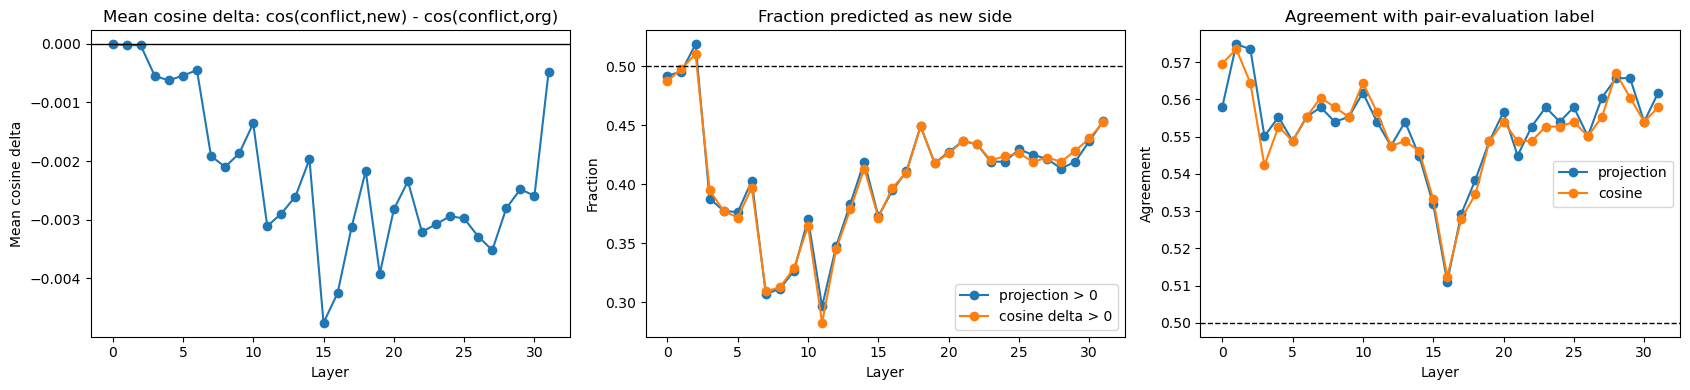

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(layer_summary['layer'], layer_summary['mean_cosine_delta'], marker='o')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Mean cosine delta: cos(conflict,new) - cos(conflict,org)')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Mean cosine delta')

axes[1].plot(layer_summary['layer'], layer_summary['frac_projection_new'], marker='o', label='projection > 0')
axes[1].plot(layer_summary['layer'], layer_summary['frac_cosine_new'], marker='o', label='cosine delta > 0')
axes[1].axhline(0.5, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Fraction predicted as new side')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Fraction')
axes[1].legend()

if not agreement_by_layer.empty:
    axes[2].plot(agreement_by_layer['layer'], agreement_by_layer['projection_agreement'], marker='o', label='projection')
    axes[2].plot(agreement_by_layer['layer'], agreement_by_layer['cosine_agreement'], marker='o', label='cosine')
axes[2].axhline(0.5, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Agreement with pair-evaluation label')
axes[2].set_xlabel('Layer')
axes[2].set_ylabel('Agreement')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'layer_curves.png', dpi=200)
plt.show()

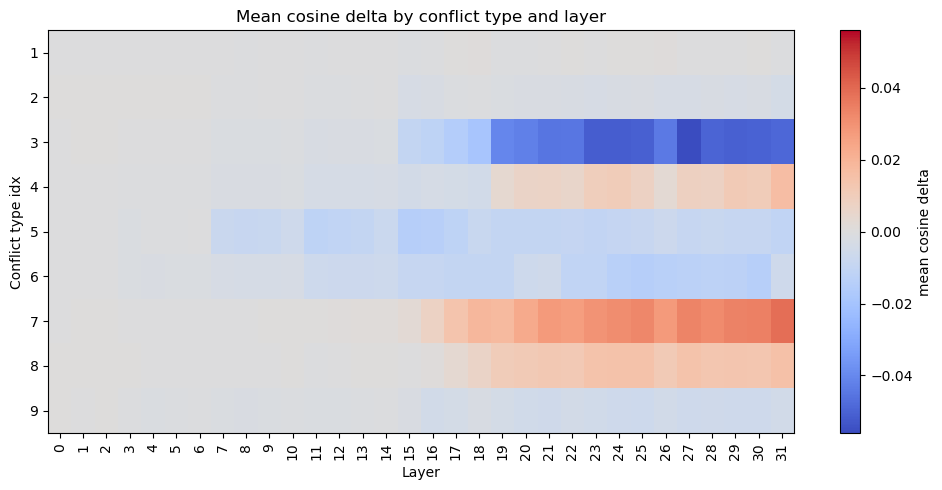

In [7]:
pivot = type_summary.pivot(index='layer', columns='conflict_type_idx', values='mean_cosine_delta')
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.T, aspect='auto', cmap='coolwarm', vmin=-np.nanmax(abs(pivot.values)), vmax=np.nanmax(abs(pivot.values)))
ax.set_title('Mean cosine delta by conflict type and layer')
ax.set_xlabel('Layer')
ax.set_ylabel('Conflict type idx')
ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.index, rotation=90)
ax.set_yticks(range(len(pivot.columns)))
ax.set_yticklabels(pivot.columns)
fig.colorbar(im, ax=ax, label='mean cosine delta')
plt.tight_layout()
plt.savefig(OUT_DIR / 'type_layer_cosine_delta_heatmap.png', dpi=200)
plt.show()

In [8]:
# Inspect layers where projection best agrees with pair-evaluation labels.
display(agreement_by_layer.sort_values('projection_agreement', ascending=False).head(10))

# Inspect conflict-type summaries at the best projection layer.
if not agreement_by_layer.empty:
    best_layer = int(agreement_by_layer.sort_values('projection_agreement', ascending=False).iloc[0]['layer'])
    print('Best projection layer:', best_layer)
    display(type_summary[type_summary['layer'] == best_layer].sort_values('conflict_type_idx'))

print('Wrote analysis files to:', OUT_DIR)
print('\n'.join(sorted(p.name for p in OUT_DIR.iterdir())))

,layer,n_labelled,cosine_agreement,centered_cosine_agreement,projection_agreement,pair_new_rate
1,1,769.0,0.573472,0.579974,0.574772,0.474642
2,2,769.0,0.564369,0.569571,0.573472,0.474642
29,29,769.0,0.560468,0.553966,0.565670,0.474642
28,28,769.0,0.566970,0.559168,0.565670,0.474642
31,31,769.0,0.557867,0.552666,0.561769,0.474642
10,10,769.0,0.564369,0.570871,0.561769,0.474642
27,27,769.0,0.555267,0.556567,0.560468,0.474642
25,25,769.0,0.553966,0.551365,0.557867,0.474642
23,23,769.0,0.552666,0.548765,0.557867,0.474642
0,0,769.0,0.569571,0.573472,0.557867,0.474642


Best projection layer: 1


,conflict_type_idx,layer,n,mean_cosine_delta,frac_cosine_new,mean_centered_cosine_delta,frac_centered_cosine_new,mean_projection,frac_projection_new
1,1,1,100,-0.000028,0.430000,-0.005329,0.450000,-0.003049,0.440000
33,2,1,100,0.000018,0.540000,0.003888,0.550000,0.002079,0.520000
65,3,1,100,0.000012,0.530000,0.002153,0.460000,0.000745,0.500000
97,4,1,100,-0.000021,0.460000,-0.005330,0.460000,-0.001959,0.450000
129,5,1,100,-0.000038,0.410000,-0.009968,0.430000,-0.002667,0.430000
161,6,1,100,-0.000161,0.350000,-0.029251,0.370000,-0.008881,0.350000
193,7,1,100,0.000005,0.500000,0.000643,0.500000,-0.000520,0.530000
225,8,1,94,0.000062,0.712766,0.014291,0.712766,0.008139,0.702128
257,9,1,70,-0.000008,0.585714,0.002716,0.557143,-0.000532,0.571429


Wrote analysis files to: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/analysis/coninstruct_projection/Qwen__Qwen3.5-4B
agreement_by_layer.csv
layer_curves.png
layer_summary.csv
sample_layer_scores.csv
type_layer_cosine_delta_heatmap.png
type_layer_summary.csv


## Classifier analysis

The projection/cosine rules above are zero-shot rules. This section fits simple classifiers to test whether the hidden-state geometry carries more predictive signal when the decision boundary is learned from data. We only train on samples where the pair-evaluation label is `org` or `new`; `neither` is excluded because this is a binary classifier.

In [9]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

CLASSIFIER_RANDOM_STATE = 42

# Feature groups are evaluated as all-layer classifiers. For each group, every
# feature is expanded across all layers, e.g. cos_org_layer_0 ... cos_org_layer_31.
FEATURE_GROUPS = {
    'raw_cos': ['cos_org', 'cos_new'],
    'centered_cos': ['centered_cos_org', 'centered_cos_new'],
    'projection': ['projection'],
    'normalized_projection': ['normalized_projection'],
    'all_geometry_no_delta': [
        'cos_org',
        'cos_new',
        'centered_cos_org',
        'centered_cos_new',
        'projection',
        'normalized_projection',
    ],
    # Delta features are linear combinations of the two cosine endpoints, so this
    # group is diagnostic rather than the main specification.
    'delta_only': ['cosine_delta', 'centered_cosine_delta'],
    'all_geometry_with_delta': [
        'cos_org',
        'cos_new',
        'cosine_delta',
        'centered_cos_org',
        'centered_cos_new',
        'centered_cosine_delta',
        'projection',
        'normalized_projection',
    ],
}

CLASSIFIER_MODELS = {
    'logistic_l2': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=CLASSIFIER_RANDOM_STATE),
    ),
    'linear_svm': make_pipeline(
        StandardScaler(),
        LinearSVC(class_weight='balanced', dual='auto', max_iter=10000, random_state=CLASSIFIER_RANDOM_STATE),
    ),
    'rbf_svm': make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=CLASSIFIER_RANDOM_STATE),
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=CLASSIFIER_RANDOM_STATE,
        n_jobs=-1,
    ),
    'extra_trees': ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=CLASSIFIER_RANDOM_STATE,
        n_jobs=-1,
    ),
    'gradient_boosting': GradientBoostingClassifier(random_state=CLASSIFIER_RANDOM_STATE),
}

# Backward-compatible default used by the optional per-layer diagnostic cell.
CLASSIFIER_FEATURES = FEATURE_GROUPS['all_geometry_no_delta']

labelled_scores = scores[scores['pair_label_name'].isin(['org', 'new'])].copy()
labelled_scores['y'] = (labelled_scores['pair_label_name'] == 'new').astype(int)


def classifier_score_vector(clf, X):
    if hasattr(clf, 'predict_proba'):
        return clf.predict_proba(X)[:, 1]
    if hasattr(clf, 'decision_function'):
        return clf.decision_function(X)
    return clf.predict(X)


def cross_validate_binary_classifier(X, y, estimator=None, n_splits=5):
    if estimator is None:
        estimator = CLASSIFIER_MODELS['logistic_l2']
    y = np.asarray(y)
    X = np.asarray(X)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=CLASSIFIER_RANDOM_STATE)
    rows = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        clf = clone(estimator)
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[test_idx])
        score = classifier_score_vector(clf, X[test_idx])
        rows.append({
            'fold': fold_idx,
            'n_train': len(train_idx),
            'n_test': len(test_idx),
            'accuracy': accuracy_score(y[test_idx], pred),
            'balanced_accuracy': balanced_accuracy_score(y[test_idx], pred),
            'roc_auc': roc_auc_score(y[test_idx], score),
        })
    return pd.DataFrame(rows)


def summarize_cv(cv_df, name):
    metrics = ['accuracy', 'balanced_accuracy', 'roc_auc']
    out = {'name': name, 'n_folds': len(cv_df)}
    for metric in metrics:
        out[f'{metric}_mean'] = cv_df[metric].mean()
        out[f'{metric}_std'] = cv_df[metric].std(ddof=1)
    return out


def build_all_layer_feature_matrix(labelled_scores, feature_names):
    id_cols = ['conflict_type_idx', 'sample_id']
    wide_parts = []
    for feature in feature_names:
        part = labelled_scores.pivot_table(index=id_cols, columns='layer', values=feature, aggfunc='first')
        part.columns = [f'{feature}_layer_{int(layer)}' for layer in part.columns]
        wide_parts.append(part)
    X_wide = pd.concat(wide_parts, axis=1).sort_index()
    y_wide = (
        labelled_scores.drop_duplicates(id_cols)
        .set_index(id_cols)
        .loc[X_wide.index, 'y']
        .to_numpy(dtype=np.int64)
    )
    return X_wide, y_wide

print('Binary labelled rows:', len(labelled_scores))
print(labelled_scores[['conflict_type_idx', 'sample_id']].drop_duplicates().shape[0], 'unique samples')
print('Feature groups:')
for group_name, feature_names in FEATURE_GROUPS.items():
    print(f'  {group_name}: {feature_names}')
print('Classifier models:', ', '.join(CLASSIFIER_MODELS))
labelled_scores[['pair_label_name', 'y']].drop_duplicates().sort_values('y')


Binary labelled rows: 24608
769 unique samples
Feature groups:
  raw_cos: ['cos_org', 'cos_new']
  centered_cos: ['centered_cos_org', 'centered_cos_new']
  projection: ['projection']
  normalized_projection: ['normalized_projection']
  all_geometry_no_delta: ['cos_org', 'cos_new', 'centered_cos_org', 'centered_cos_new', 'projection', 'normalized_projection']
  delta_only: ['cosine_delta', 'centered_cosine_delta']
  all_geometry_with_delta: ['cos_org', 'cos_new', 'cosine_delta', 'centered_cos_org', 'centered_cos_new', 'centered_cosine_delta', 'projection', 'normalized_projection']
Classifier models: logistic_l2, linear_svm, rbf_svm, random_forest, extra_trees, gradient_boosting


,pair_label_name,y
0,org,0
2,new,1


,name,n_folds,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,layer,n,new_rate
0,layer_0,5,0.630660,0.047433,0.626522,0.047344,0.647674,0.042051,0,769,0.474642
1,layer_1,5,0.616399,0.029152,0.613394,0.029685,0.642488,0.044033,1,769,0.474642
2,layer_2,5,0.599465,0.034740,0.596591,0.035403,0.638473,0.046413,2,769,0.474642
10,layer_10,5,0.568212,0.061404,0.565184,0.059468,0.588987,0.065419,10,769,0.474642
13,layer_13,5,0.560445,0.029680,0.560347,0.028169,0.559409,0.037162,13,769,0.474642
3,layer_3,5,0.556506,0.049203,0.554285,0.050087,0.554109,0.057829,3,769,0.474642
12,layer_12,5,0.553934,0.017953,0.553181,0.016054,0.555478,0.033746,12,769,0.474642
11,layer_11,5,0.555275,0.020048,0.553155,0.018772,0.566202,0.034685,11,769,0.474642
6,layer_6,5,0.551328,0.035269,0.550549,0.035614,0.568496,0.037055,6,769,0.474642
8,layer_8,5,0.552644,0.037726,0.549619,0.036741,0.577226,0.057744,8,769,0.474642


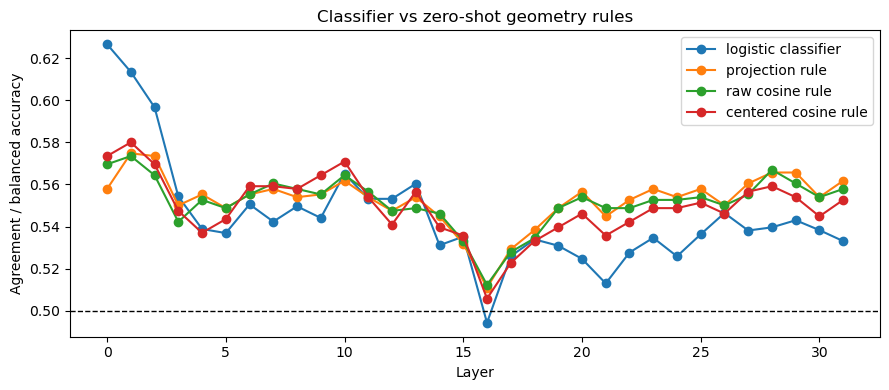

In [10]:
# Per-layer classifier: one logistic regression per layer.
per_layer_rows = []
for layer, layer_df in labelled_scores.groupby('layer'):
    X = layer_df[CLASSIFIER_FEATURES].to_numpy(dtype=np.float32)
    y = layer_df['y'].to_numpy(dtype=np.int64)
    cv_df = cross_validate_binary_classifier(X, y)
    row = summarize_cv(cv_df, f'layer_{layer}')
    row['layer'] = int(layer)
    row['n'] = len(layer_df)
    row['new_rate'] = float(y.mean())
    per_layer_rows.append(row)

classifier_by_layer = pd.DataFrame(per_layer_rows).sort_values('layer')
classifier_by_layer.to_csv(OUT_DIR / 'classifier_by_layer.csv', index=False)

display(classifier_by_layer.sort_values('balanced_accuracy_mean', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(classifier_by_layer['layer'], classifier_by_layer['balanced_accuracy_mean'], marker='o', label='logistic classifier')
ax.plot(agreement_by_layer['layer'], agreement_by_layer['projection_agreement'], marker='o', label='projection rule')
ax.plot(agreement_by_layer['layer'], agreement_by_layer['cosine_agreement'], marker='o', label='raw cosine rule')
ax.plot(agreement_by_layer['layer'], agreement_by_layer['centered_cosine_agreement'], marker='o', label='centered cosine rule')
ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Layer')
ax.set_ylabel('Agreement / balanced accuracy')
ax.set_title('Classifier vs zero-shot geometry rules')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'classifier_by_layer.png', dpi=200)
plt.show()

In [11]:
# All-layer classifier comparison: each sample becomes one row and every selected
# geometry score is expanded across all layers. This cell compares feature groups
# and classifier families.
classifier_summary_rows = []
classifier_cv_frames = []
feature_matrix_shapes = []

# A baseline that only predicts the majority class under the same folds.
baseline_X, baseline_y = build_all_layer_feature_matrix(labelled_scores, FEATURE_GROUPS['raw_cos'])
dummy = DummyClassifier(strategy='most_frequent')
dummy_cv = cross_validate_binary_classifier(baseline_X.to_numpy(dtype=np.float32), baseline_y, estimator=dummy)
baseline_summary = summarize_cv(dummy_cv, 'majority_baseline')
baseline_summary.update({
    'feature_group': 'majority_baseline',
    'classifier_model': 'majority_baseline',
    'n_samples': baseline_X.shape[0],
    'n_features': 0,
    'feature_names': '',
})
classifier_summary_rows.append(baseline_summary)
classifier_cv_frames.append(dummy_cv.assign(feature_group='majority_baseline', classifier_model='majority_baseline'))

for group_name, feature_names in FEATURE_GROUPS.items():
    X_wide, y_wide = build_all_layer_feature_matrix(labelled_scores, feature_names)
    X_np = X_wide.to_numpy(dtype=np.float32)
    feature_matrix_shapes.append({
        'feature_group': group_name,
        'n_samples': X_wide.shape[0],
        'n_features': X_wide.shape[1],
        'feature_names': ','.join(feature_names),
    })
    for model_name, estimator in CLASSIFIER_MODELS.items():
        print(f'Running {group_name} / {model_name} ...')
        cv_df = cross_validate_binary_classifier(X_np, y_wide, estimator=estimator)
        summary = summarize_cv(cv_df, f'{group_name}__{model_name}')
        summary.update({
            'feature_group': group_name,
            'classifier_model': model_name,
            'n_samples': X_wide.shape[0],
            'n_features': X_wide.shape[1],
            'feature_names': ','.join(feature_names),
        })
        classifier_summary_rows.append(summary)
        classifier_cv_frames.append(cv_df.assign(feature_group=group_name, classifier_model=model_name))

classifier_summary = pd.DataFrame(classifier_summary_rows)
classifier_all_layer_cv = pd.concat(classifier_cv_frames, ignore_index=True)
classifier_feature_shapes = pd.DataFrame(feature_matrix_shapes)

ordered_cols = [
    'feature_group',
    'classifier_model',
    'name',
    'n_folds',
    'n_samples',
    'n_features',
    'accuracy_mean',
    'accuracy_std',
    'balanced_accuracy_mean',
    'balanced_accuracy_std',
    'roc_auc_mean',
    'roc_auc_std',
    'feature_names',
]
classifier_summary = classifier_summary[ordered_cols]

classifier_summary.to_csv(OUT_DIR / 'classifier_summary.csv', index=False)
classifier_all_layer_cv.to_csv(OUT_DIR / 'classifier_all_layers_cv_folds.csv', index=False)
classifier_feature_shapes.to_csv(OUT_DIR / 'classifier_feature_shapes.csv', index=False)

display(classifier_summary.sort_values('balanced_accuracy_mean', ascending=False).head(20))
print('Wrote classifier outputs to:', OUT_DIR)
print('\n'.join(sorted(p.name for p in OUT_DIR.glob('classifier*'))))


Running raw_cos / logistic_l2 ...
Running raw_cos / linear_svm ...
Running raw_cos / rbf_svm ...
Running raw_cos / random_forest ...
Running raw_cos / extra_trees ...
Running raw_cos / gradient_boosting ...
Running centered_cos / logistic_l2 ...
Running centered_cos / linear_svm ...
Running centered_cos / rbf_svm ...
Running centered_cos / random_forest ...
Running centered_cos / extra_trees ...
Running centered_cos / gradient_boosting ...
Running projection / logistic_l2 ...
Running projection / linear_svm ...
Running projection / rbf_svm ...
Running projection / random_forest ...
Running projection / extra_trees ...
Running projection / gradient_boosting ...
Running normalized_projection / logistic_l2 ...
Running normalized_projection / linear_svm ...
Running normalized_projection / rbf_svm ...
Running normalized_projection / random_forest ...
Running normalized_projection / extra_trees ...
Running normalized_projection / gradient_boosting ...
Running all_geometry_no_delta / logistic

,feature_group,classifier_model,name,n_folds,n_samples,n_features,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,feature_names
37,all_geometry_with_delta,logistic_l2,all_geometry_with_delta__logistic_l2,5,769,256,0.690485,0.040141,0.688651,0.039251,0.718555,0.035960,"cos_org,cos_new,cosine_delta,centered_cos_org,..."
25,all_geometry_no_delta,logistic_l2,all_geometry_no_delta__logistic_l2,5,769,192,0.678745,0.043090,0.677238,0.043044,0.716793,0.035036,"cos_org,cos_new,centered_cos_org,centered_cos_..."
27,all_geometry_no_delta,rbf_svm,all_geometry_no_delta__rbf_svm,5,769,192,0.674875,0.033768,0.673399,0.034521,0.728236,0.046848,"cos_org,cos_new,centered_cos_org,centered_cos_..."
41,all_geometry_with_delta,extra_trees,all_geometry_with_delta__extra_trees,5,769,256,0.672320,0.023361,0.670737,0.023030,0.717415,0.026738,"cos_org,cos_new,cosine_delta,centered_cos_org,..."
26,all_geometry_no_delta,linear_svm,all_geometry_no_delta__linear_svm,5,769,192,0.670962,0.040871,0.669108,0.040106,0.701695,0.037519,"cos_org,cos_new,centered_cos_org,centered_cos_..."
2,raw_cos,linear_svm,raw_cos__linear_svm,5,769,64,0.667100,0.026127,0.663212,0.025120,0.696029,0.037458,"cos_org,cos_new"
39,all_geometry_with_delta,rbf_svm,all_geometry_with_delta__rbf_svm,5,769,256,0.664477,0.032304,0.662696,0.032502,0.727221,0.045814,"cos_org,cos_new,cosine_delta,centered_cos_org,..."
11,centered_cos,extra_trees,centered_cos__extra_trees,5,769,64,0.661879,0.011016,0.659627,0.012484,0.690601,0.029742,"centered_cos_org,centered_cos_new"
29,all_geometry_no_delta,extra_trees,all_geometry_no_delta__extra_trees,5,769,192,0.661905,0.036070,0.659596,0.036907,0.715469,0.035411,"cos_org,cos_new,centered_cos_org,centered_cos_..."
5,raw_cos,extra_trees,raw_cos__extra_trees,5,769,64,0.657966,0.051927,0.655320,0.050540,0.698975,0.038992,"cos_org,cos_new"


Wrote classifier outputs to: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/analysis/coninstruct_projection/Qwen__Qwen3.5-4B
classifier_all_layers_cv_folds.csv
classifier_by_layer.csv
classifier_by_layer.png
classifier_feature_shapes.csv
classifier_summary.csv


## t-SNE by final evaluation label

This section visualizes the full conflicting-prompt hidden vectors `h_conflict` with t-SNE. Points are colored by the final order-corrected pair-evaluation label: `1 = new`, `2 = org`, and `-1 = neither`. The labels come from `pair_label`, not `pair_raw_label`, so order randomization in the pairwise judge prompt has already been corrected.

In [12]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

TSNE_LAYERS = list(range(32)) #[0, 2, 21, 31]
TSNE_PCA_COMPONENTS = 50
TSNE_PERPLEXITY = 30
TSNE_RANDOM_STATE = 42

LABEL_STYLE = {
    -1: {'name': 'neither', 'color': '#7f7f7f', 'marker': 'x'},
    1: {'name': 'new', 'color': '#d62728', 'marker': 'o'},
    2: {'name': 'org', 'color': '#1f77b4', 'marker': '^'},
}

def load_conflict_hidden_layer(layer):
    rows = []
    arrays = []
    for conflict_type_idx in sorted(conflict_examples['conflict_type_idx'].astype(int).unique()):
        type_examples = (
            conflict_examples[conflict_examples['conflict_type_idx'].astype(int) == conflict_type_idx]
            .reset_index(drop=True)
        )
        layer_path = CONFLICT_HIDDEN_ROOT / f'conflict_type_{conflict_type_idx}' / f'layer_{layer}.npy'
        arr = np.load(layer_path)
        if len(type_examples) != arr.shape[0]:
            raise ValueError(
                f'Layer {layer} conflict_type_{conflict_type_idx}: '
                f'{arr.shape[0]} vectors but {len(type_examples)} metadata rows'
            )
        arrays.append(arr.astype(np.float32, copy=False))
        for row_idx, ex in type_examples.iterrows():
            rows.append({
                'conflict_type_idx': int(ex['conflict_type_idx']),
                'sample_id': int(ex['sample_id']),
                'hidden_row': row_idx,
            })
    return np.vstack(arrays), pd.DataFrame(rows)

def tsne_for_layer(layer):
    X, meta = load_conflict_hidden_layer(layer)
    labels = scores[[
        'conflict_type_idx',
        'sample_id',
        'pair_label',
        'pair_label_name',
        'behavior_label',
        'behavior_label_name',
    ]].drop_duplicates(['conflict_type_idx', 'sample_id'])
    meta = meta.merge(labels, on=['conflict_type_idx', 'sample_id'], how='left')

    X_scaled = StandardScaler().fit_transform(X)
    n_components = min(TSNE_PCA_COMPONENTS, X_scaled.shape[0] - 1, X_scaled.shape[1])
    if n_components >= 2:
        X_reduced = PCA(n_components=n_components, random_state=TSNE_RANDOM_STATE).fit_transform(X_scaled)
    else:
        X_reduced = X_scaled

    perplexity = min(TSNE_PERPLEXITY, max(5, (len(meta) - 1) // 3))
    coords = TSNE(
        n_components=2,
        perplexity=perplexity,
        init='pca',
        learning_rate='auto',
        random_state=TSNE_RANDOM_STATE,
    ).fit_transform(X_reduced)

    out = meta.copy()
    out['layer'] = int(layer)
    out['tsne_x'] = coords[:, 0]
    out['tsne_y'] = coords[:, 1]
    return out

tsne_frames = []
for layer in TSNE_LAYERS:
    print(f'Running t-SNE for layer {layer}...')
    tsne_frames.append(tsne_for_layer(layer))

tsne_df = pd.concat(tsne_frames, ignore_index=True)
tsne_df.to_csv(OUT_DIR / 'tsne_conflict_hidden_states.csv', index=False)

print('Wrote:', OUT_DIR / 'tsne_conflict_hidden_states.csv')
display(tsne_df.groupby(['layer', 'pair_label', 'pair_label_name']).size().reset_index(name='n'))

Running t-SNE for layer 0...
Running t-SNE for layer 1...
Running t-SNE for layer 2...
Running t-SNE for layer 3...
Running t-SNE for layer 4...
Running t-SNE for layer 5...
Running t-SNE for layer 6...
Running t-SNE for layer 7...
Running t-SNE for layer 8...
Running t-SNE for layer 9...
Running t-SNE for layer 10...
Running t-SNE for layer 11...
Running t-SNE for layer 12...
Running t-SNE for layer 13...
Running t-SNE for layer 14...
Running t-SNE for layer 15...
Running t-SNE for layer 16...
Running t-SNE for layer 17...
Running t-SNE for layer 18...
Running t-SNE for layer 19...
Running t-SNE for layer 20...
Running t-SNE for layer 21...
Running t-SNE for layer 22...
Running t-SNE for layer 23...
Running t-SNE for layer 24...
Running t-SNE for layer 25...
Running t-SNE for layer 26...
Running t-SNE for layer 27...
Running t-SNE for layer 28...
Running t-SNE for layer 29...
Running t-SNE for layer 30...
Running t-SNE for layer 31...
Wrote: /Users/xinmingwang/Library/CloudStorage/One

,layer,pair_label,pair_label_name,n
0,0,-1,neither,95
1,0,1,new,365
2,0,2,org,404
3,1,-1,neither,95
4,1,1,new,365
...,...,...,...,...
91,30,1,new,365
92,30,2,org,404
93,31,-1,neither,95
94,31,1,new,365


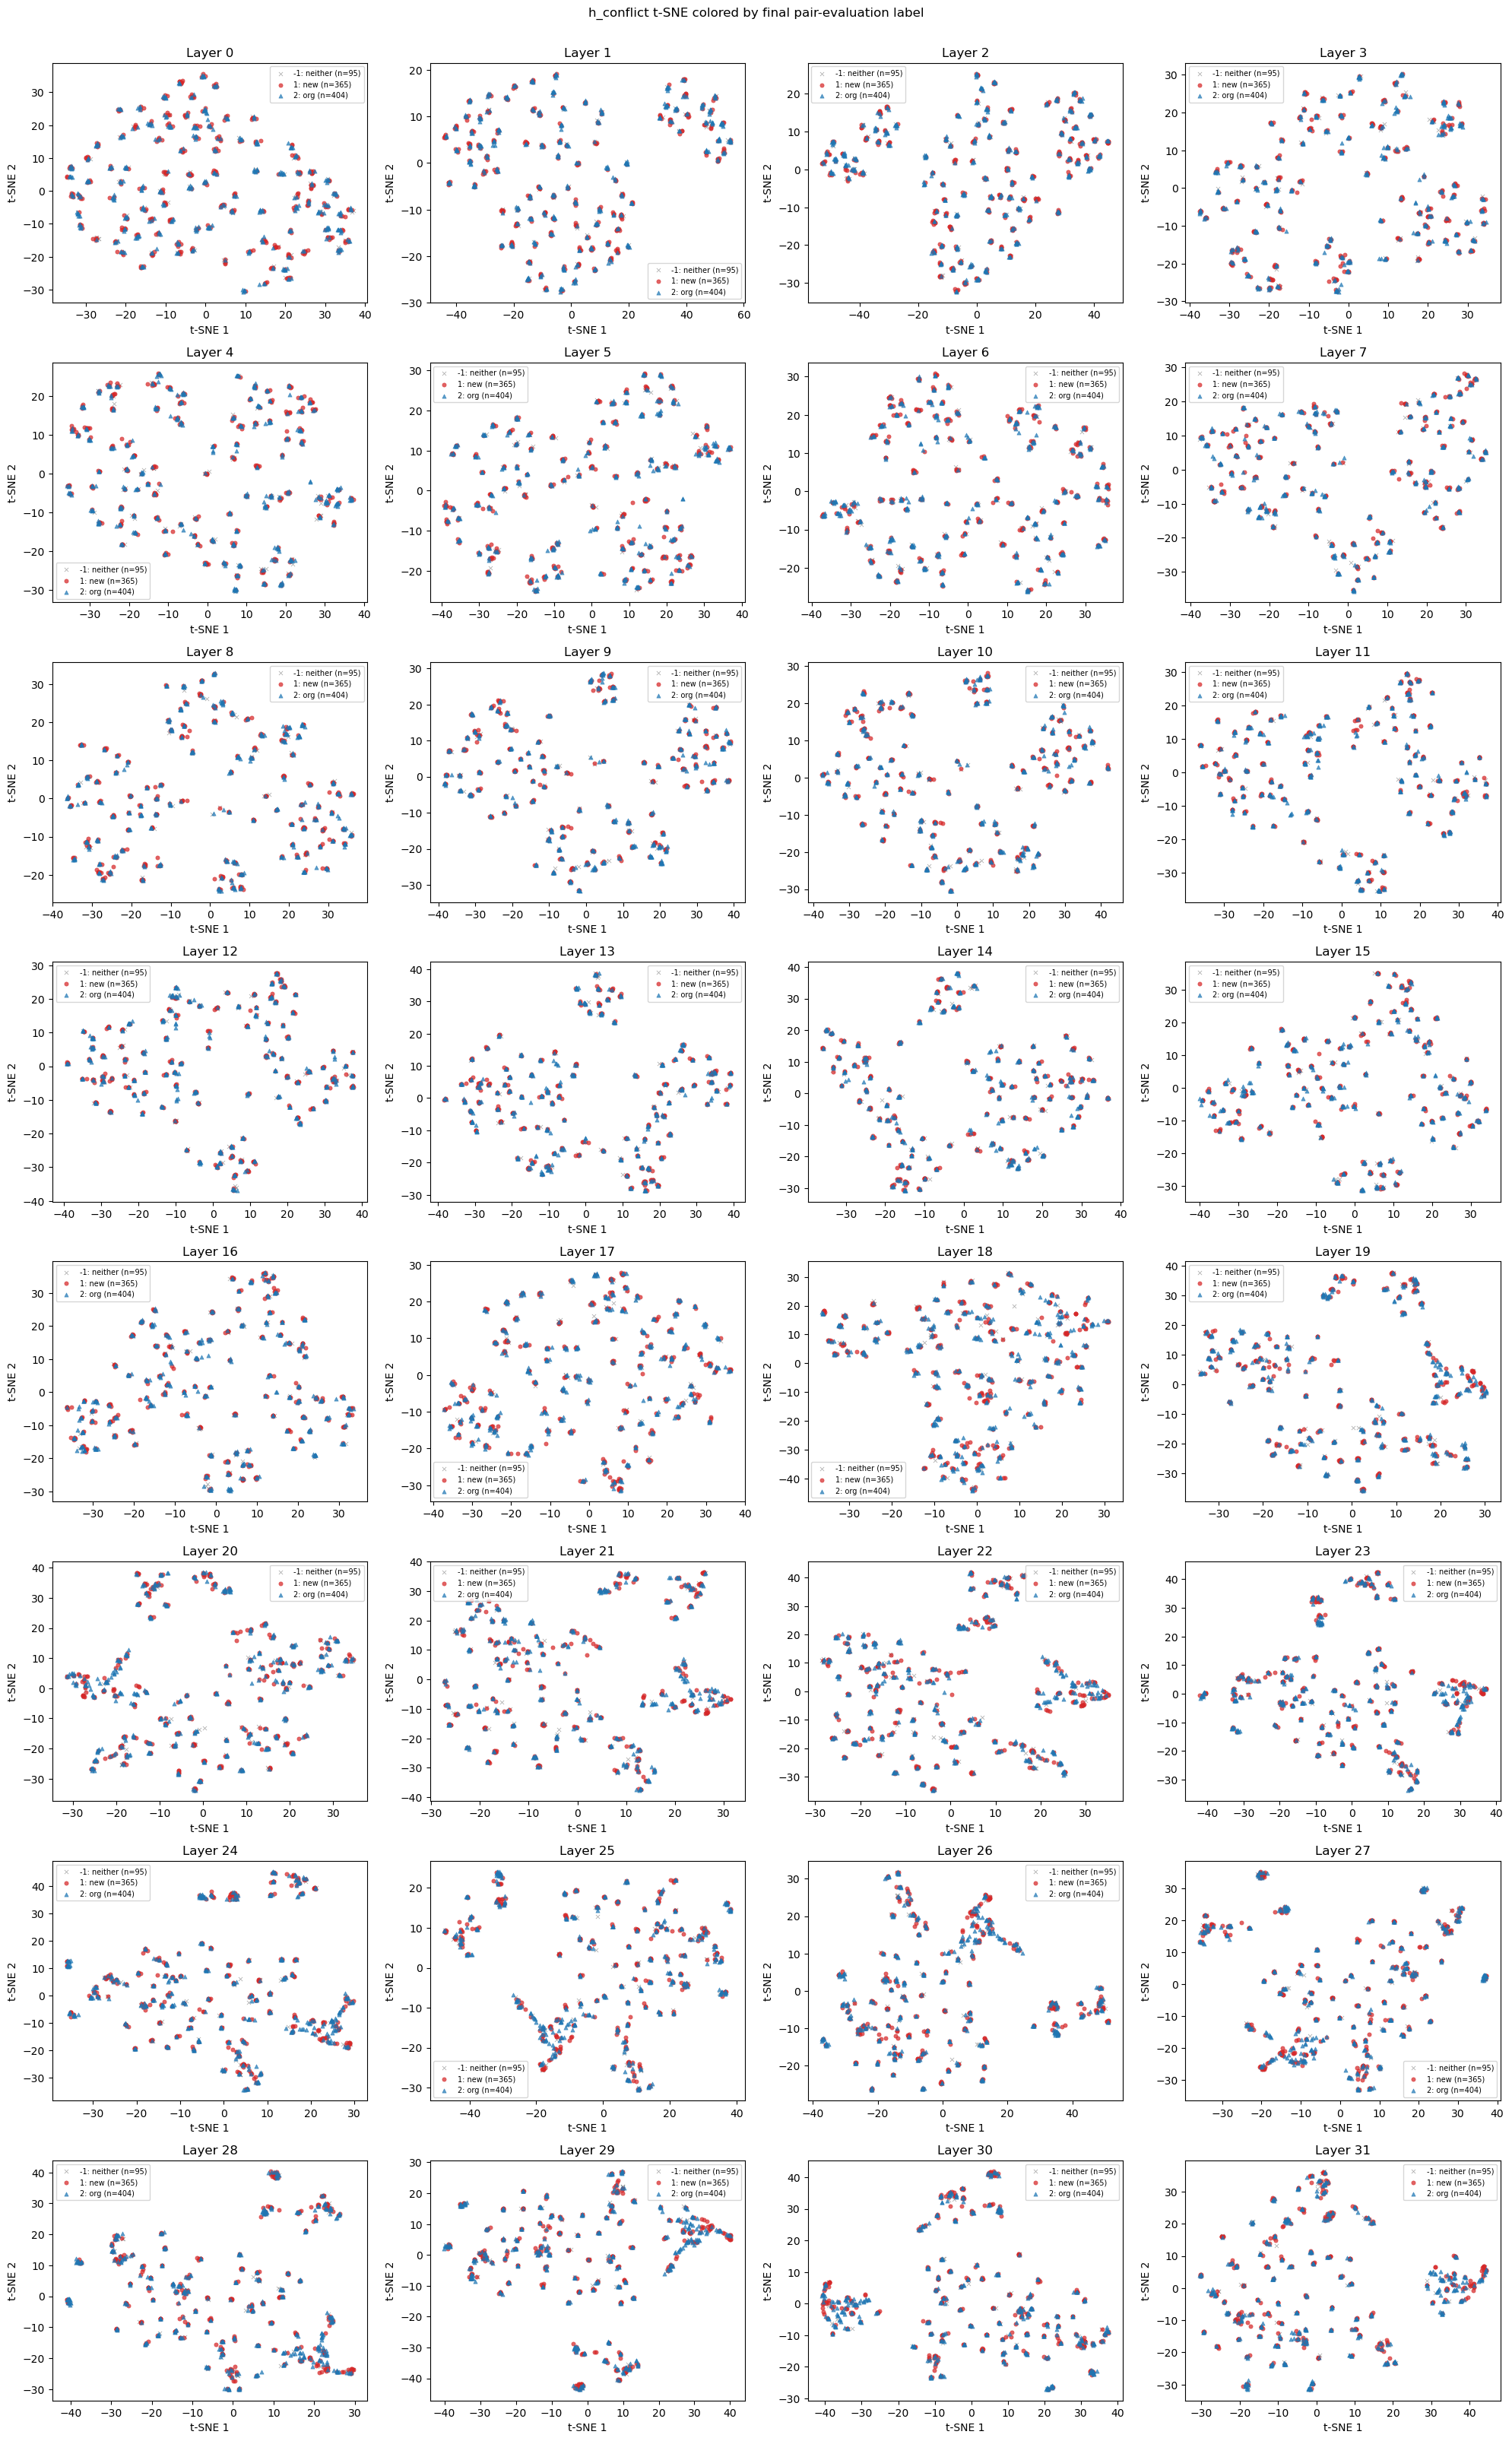

Wrote: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/analysis/coninstruct_projection/Qwen__Qwen3.5-4B/tsne_conflict_hidden_states_all_layers.png
Wrote per-layer plots to: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/analysis/coninstruct_projection/Qwen__Qwen3.5-4B/tsne_by_layer
tsne_layer_00.png
tsne_layer_01.png
tsne_layer_02.png
tsne_layer_03.png
tsne_layer_04.png
tsne_layer_05.png
tsne_layer_06.png
tsne_layer_07.png
tsne_layer_08.png
tsne_layer_09.png
tsne_layer_10.png
tsne_layer_11.png
tsne_layer_12.png
tsne_layer_13.png
tsne_layer_14.png
tsne_layer_15.png
tsne_layer_16.png
tsne_layer_17.png
tsne_layer_18.png
tsne_layer_19.png
tsne_layer_20.png
tsne_layer_21.png
tsne_layer_22.png
tsne_layer_23.png
tsne_layer_24.png
tsne_layer_25.png
tsne_layer_26.png
tsne_layer_27.png
tsne_layer_28.png
tsne_layer_29.png
tsne_layer_30.png
tsne_layer_31.png


In [13]:
TSNE_SINGLE_DIR = OUT_DIR / 'tsne_by_layer'
TSNE_SINGLE_DIR.mkdir(exist_ok=True)

n_cols = 4
n_rows = int(np.ceil(len(TSNE_LAYERS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
axes = axes.ravel()

for ax_idx, ax in enumerate(axes):
    if ax_idx >= len(TSNE_LAYERS):
        ax.axis('off')
        continue

    layer = TSNE_LAYERS[ax_idx]
    layer_df = tsne_df[tsne_df['layer'] == layer]
    for label, style in LABEL_STYLE.items():
        sub = layer_df[layer_df['pair_label'] == label]
        if sub.empty:
            continue
        ax.scatter(
            sub['tsne_x'],
            sub['tsne_y'],
            s=14,
            alpha=0.72,
            c=style['color'],
            marker=style['marker'],
            label=f"{label}: {style['name']} (n={len(sub)})",
            linewidths=0.5,
        )
    ax.set_title(f'Layer {layer}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=7, frameon=True)

fig.suptitle('h_conflict t-SNE colored by final pair-evaluation label', y=1.002)
fig.tight_layout()
overview_path = OUT_DIR / 'tsne_conflict_hidden_states_all_layers.png'
fig.savefig(overview_path, dpi=220, bbox_inches='tight')
plt.show()
print('Wrote:', overview_path)

# Also save one readable image per layer.
for layer in TSNE_LAYERS:
    layer_df = tsne_df[tsne_df['layer'] == layer]
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    for label, style in LABEL_STYLE.items():
        sub = layer_df[layer_df['pair_label'] == label]
        if sub.empty:
            continue
        ax.scatter(
            sub['tsne_x'],
            sub['tsne_y'],
            s=24,
            alpha=0.78,
            c=style['color'],
            marker=style['marker'],
            label=f"{label}: {style['name']} (n={len(sub)})",
            linewidths=0.7,
        )
    ax.set_title(f'h_conflict t-SNE: layer {layer}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8, frameon=True)
    fig.tight_layout()
    layer_path = TSNE_SINGLE_DIR / f'tsne_layer_{layer:02d}.png'
    fig.savefig(layer_path, dpi=220, bbox_inches='tight')
    plt.close(fig)

print('Wrote per-layer plots to:', TSNE_SINGLE_DIR)
print('\n'.join(sorted(p.name for p in TSNE_SINGLE_DIR.glob('tsne_layer_*.png'))))


## Per-layer mean geometry by final label

This section groups samples by the final order-corrected pair-evaluation label, keeping only `1 = new` and `2 = org`, then plots the mean cosine/projection geometry at each layer.

,pair_label,pair_label_display,layer,n,mean_cos_org,mean_cos_new,mean_cosine_delta,mean_centered_cos_org,mean_centered_cos_new,mean_centered_cosine_delta,mean_projection,mean_normalized_projection
0,1,1: new,0,365,0.999874,0.999878,0.000004,0.893114,0.895729,0.002615,0.001063,0.128843
1,1,1: new,1,365,0.999670,0.999672,0.000002,0.923996,0.925309,0.001313,0.001485,0.099022
2,1,1: new,2,365,0.999053,0.999081,0.000028,0.914498,0.918552,0.004053,0.003985,0.138724
3,1,1: new,3,365,0.997297,0.996893,-0.000404,0.935986,0.927703,-0.008283,-0.011706,-0.066611
4,1,1: new,4,365,0.996134,0.995745,-0.000389,0.934686,0.927797,-0.006889,-0.016811,-0.085850


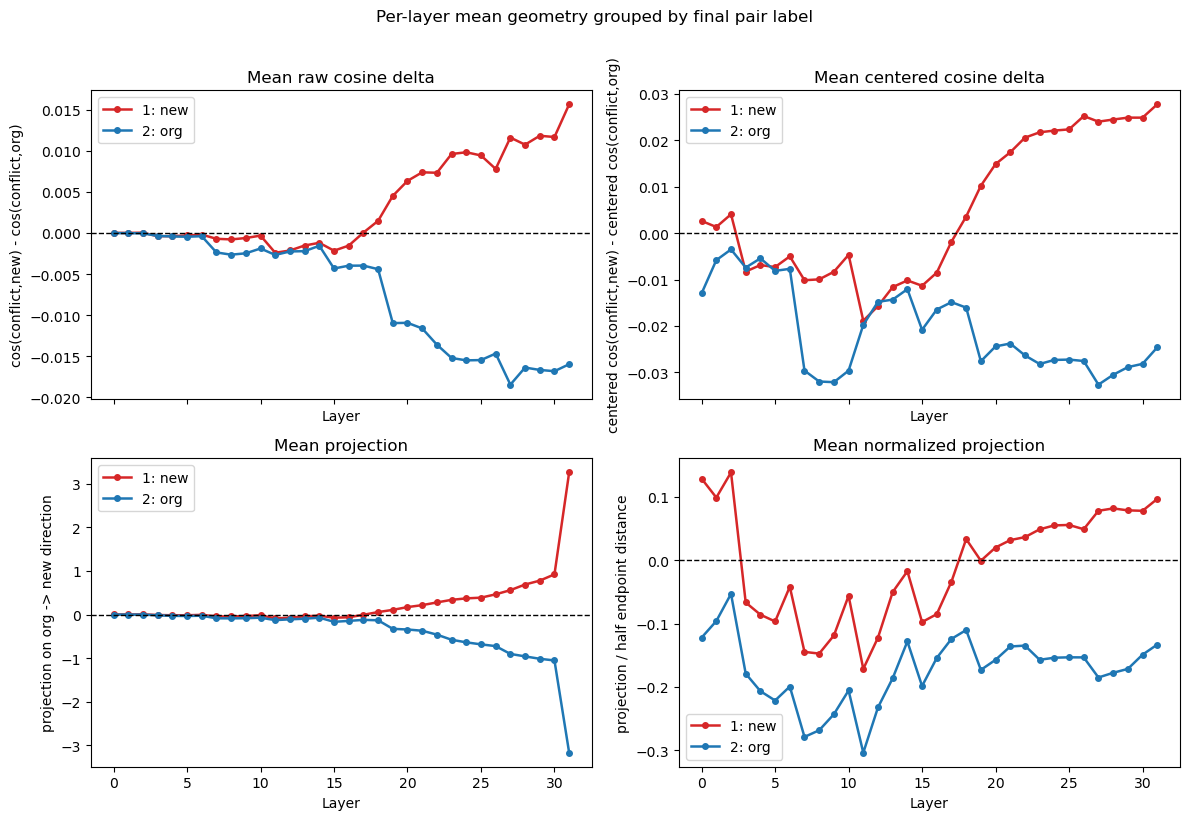

Wrote: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/analysis/coninstruct_projection/Qwen__Qwen3.5-4B/label_layer_mean_geometry.csv
Wrote: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/analysis/coninstruct_projection/Qwen__Qwen3.5-4B/label_layer_mean_geometry.png


In [14]:
labelled_for_curves = scores[scores['pair_label'].isin([1, 2])].copy()
labelled_for_curves['pair_label_display'] = labelled_for_curves['pair_label'].map({1: '1: new', 2: '2: org'})

label_layer_mean_geometry = (
    labelled_for_curves
    .groupby(['pair_label', 'pair_label_display', 'layer'])
    .agg(
        n=('sample_id', 'count'),
        mean_cos_org=('cos_org', 'mean'),
        mean_cos_new=('cos_new', 'mean'),
        mean_cosine_delta=('cosine_delta', 'mean'),
        mean_centered_cos_org=('centered_cos_org', 'mean'),
        mean_centered_cos_new=('centered_cos_new', 'mean'),
        mean_centered_cosine_delta=('centered_cosine_delta', 'mean'),
        mean_projection=('projection', 'mean'),
        mean_normalized_projection=('normalized_projection', 'mean'),
    )
    .reset_index()
)

label_layer_mean_geometry.to_csv(OUT_DIR / 'label_layer_mean_geometry.csv', index=False)
display(label_layer_mean_geometry.head())

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
plot_specs = [
    ('mean_cosine_delta', 'Mean raw cosine delta', 'cos(conflict,new) - cos(conflict,org)'),
    ('mean_centered_cosine_delta', 'Mean centered cosine delta', 'centered cos(conflict,new) - centered cos(conflict,org)'),
    ('mean_projection', 'Mean projection', 'projection on org -> new direction'),
    ('mean_normalized_projection', 'Mean normalized projection', 'projection / half endpoint distance'),
]
colors = {1: '#d62728', 2: '#1f77b4'}

for ax, (metric, title, ylabel) in zip(axes.ravel(), plot_specs):
    for pair_label, group in label_layer_mean_geometry.groupby('pair_label'):
        group = group.sort_values('layer')
        ax.plot(
            group['layer'],
            group[metric],
            marker='o',
            linewidth=1.8,
            markersize=4,
            color=colors[pair_label],
            label=group['pair_label_display'].iloc[0],
        )
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Layer')
    ax.set_ylabel(ylabel)
    ax.legend()

fig.suptitle('Per-layer mean geometry grouped by final pair label', y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / 'label_layer_mean_geometry.png', dpi=220, bbox_inches='tight')
plt.show()
print('Wrote:', OUT_DIR / 'label_layer_mean_geometry.csv')
print('Wrote:', OUT_DIR / 'label_layer_mean_geometry.png')


## Per-layer mean raw geometry values by final label

This section avoids cosine differences and plots the original mean similarity values directly: `cos_org` and `cos_new`, plus their centered versions. Projection values are kept as their original signed scalar values.

,pair_label,pair_label_display,layer,n,mean_cos_org,mean_cos_new,mean_centered_cos_org,mean_centered_cos_new,mean_projection,mean_normalized_projection
0,1,1: new,0,365,0.999874,0.999878,0.893114,0.895729,0.001063,0.128843
1,1,1: new,1,365,0.999670,0.999672,0.923996,0.925309,0.001485,0.099022
2,1,1: new,2,365,0.999053,0.999081,0.914498,0.918552,0.003985,0.138724
3,1,1: new,3,365,0.997297,0.996893,0.935986,0.927703,-0.011706,-0.066611
4,1,1: new,4,365,0.996134,0.995745,0.934686,0.927797,-0.016811,-0.085850


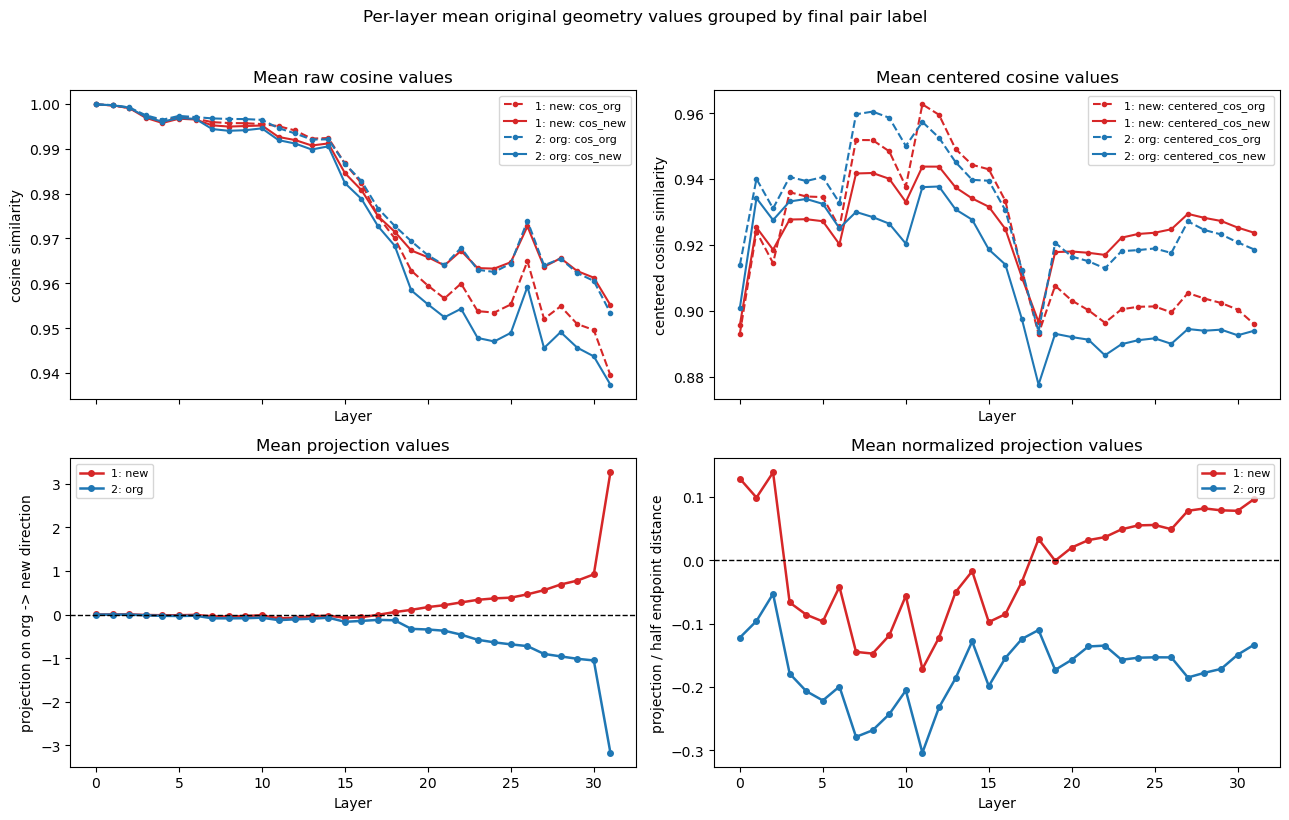

Wrote: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/analysis/coninstruct_projection/Qwen__Qwen3.5-4B/label_layer_mean_values.csv
Wrote: /Users/xinmingwang/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/Wisc/ConInstruct-master/analysis/coninstruct_projection/Qwen__Qwen3.5-4B/label_layer_mean_values.png


In [15]:
labelled_value_curves = scores[scores['pair_label'].isin([1, 2])].copy()
labelled_value_curves['pair_label_display'] = labelled_value_curves['pair_label'].map({1: '1: new', 2: '2: org'})

label_layer_mean_values = (
    labelled_value_curves
    .groupby(['pair_label', 'pair_label_display', 'layer'])
    .agg(
        n=('sample_id', 'count'),
        mean_cos_org=('cos_org', 'mean'),
        mean_cos_new=('cos_new', 'mean'),
        mean_centered_cos_org=('centered_cos_org', 'mean'),
        mean_centered_cos_new=('centered_cos_new', 'mean'),
        mean_projection=('projection', 'mean'),
        mean_normalized_projection=('normalized_projection', 'mean'),
    )
    .reset_index()
)

label_layer_mean_values.to_csv(OUT_DIR / 'label_layer_mean_values.csv', index=False)
display(label_layer_mean_values.head())

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
colors = {1: '#d62728', 2: '#1f77b4'}
linestyles = {'org': '--', 'new': '-'}

# Raw cosine endpoints.
ax = axes[0, 0]
for pair_label, group in label_layer_mean_values.groupby('pair_label'):
    group = group.sort_values('layer')
    label_prefix = group['pair_label_display'].iloc[0]
    ax.plot(group['layer'], group['mean_cos_org'], color=colors[pair_label], linestyle=linestyles['org'], marker='o', markersize=3, label=f'{label_prefix}: cos_org')
    ax.plot(group['layer'], group['mean_cos_new'], color=colors[pair_label], linestyle=linestyles['new'], marker='o', markersize=3, label=f'{label_prefix}: cos_new')
ax.set_title('Mean raw cosine values')
ax.set_xlabel('Layer')
ax.set_ylabel('cosine similarity')
ax.legend(fontsize=8)

# Centered cosine endpoints.
ax = axes[0, 1]
for pair_label, group in label_layer_mean_values.groupby('pair_label'):
    group = group.sort_values('layer')
    label_prefix = group['pair_label_display'].iloc[0]
    ax.plot(group['layer'], group['mean_centered_cos_org'], color=colors[pair_label], linestyle=linestyles['org'], marker='o', markersize=3, label=f'{label_prefix}: centered_cos_org')
    ax.plot(group['layer'], group['mean_centered_cos_new'], color=colors[pair_label], linestyle=linestyles['new'], marker='o', markersize=3, label=f'{label_prefix}: centered_cos_new')
ax.set_title('Mean centered cosine values')
ax.set_xlabel('Layer')
ax.set_ylabel('centered cosine similarity')
ax.legend(fontsize=8)

# Projection original signed value.
ax = axes[1, 0]
for pair_label, group in label_layer_mean_values.groupby('pair_label'):
    group = group.sort_values('layer')
    ax.plot(group['layer'], group['mean_projection'], color=colors[pair_label], marker='o', linewidth=1.8, markersize=4, label=group['pair_label_display'].iloc[0])
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Mean projection values')
ax.set_xlabel('Layer')
ax.set_ylabel('projection on org -> new direction')
ax.legend(fontsize=8)

# Normalized projection original signed value.
ax = axes[1, 1]
for pair_label, group in label_layer_mean_values.groupby('pair_label'):
    group = group.sort_values('layer')
    ax.plot(group['layer'], group['mean_normalized_projection'], color=colors[pair_label], marker='o', linewidth=1.8, markersize=4, label=group['pair_label_display'].iloc[0])
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Mean normalized projection values')
ax.set_xlabel('Layer')
ax.set_ylabel('projection / half endpoint distance')
ax.legend(fontsize=8)

fig.suptitle('Per-layer mean original geometry values grouped by final pair label', y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / 'label_layer_mean_values.png', dpi=220, bbox_inches='tight')
plt.show()
print('Wrote:', OUT_DIR / 'label_layer_mean_values.csv')
print('Wrote:', OUT_DIR / 'label_layer_mean_values.png')
